In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [2]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.216733,0.474449,0.228485,0.080333,1,1.172418
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012898,0.098665,0.817926,0.070511,2,1.946050
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.014049,0.108015,0.819304,0.058632,2,1.922518
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.008106,0.152586,0.646817,0.192490,2,2.023691
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.604409,0.362198,0.031458,0.001936,0,0.430922


In [3]:
blocks.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'land_value', 'site_area', 'fsi', 'gsi', 'mxi', 'l',
       'osr', 'share_living', 'share_non_living', 'morphotype',
       'area_accessibility', 'land_value_per_sqm', 'log_land_value',
       'log_land_value_per_sqm', 'land_value_class_soft_0',
       'land_value_class_soft_1', 'land_value_class_soft_2',
       'land_value_class_soft_3', 'land_value_class_pred',
       'land_value_class_soft_expected'],
      dtype='object')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) выбери колонку цены (подставь свою)
col = "land_value" 

s = pd.to_numeric(blocks[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

print("N:", len(s))
print("Mean:", s.mean())
print("Std:", s.std())
print("CV (std/mean):", s.std() / s.mean())
print("IQR:", s.quantile(0.75) - s.quantile(0.25))
print("Quantiles:\n", s.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


N: 8552
Mean: 434868482.3945136
Std: 694891695.720225
CV (std/mean): 1.5979352927440205
IQR: 421666248.427466
Quantiles:
 0.01    5.267918e+05
0.05    6.388860e+06
0.25    5.610484e+07
0.50    1.586168e+08
0.75    4.777711e+08
0.95    1.929742e+09
0.99    3.575052e+09
Name: land_value, dtype: float64


In [5]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks.select_dtypes(include=['number'])
num = num[num['log_land_value'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats

,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
residential,8552,0.00,1.00,0.51,0.68,0.43
business,8552,0.00,1.00,0.03,0.00,0.15
recreation,8552,0.00,1.00,0.19,0.00,0.33
industrial,8552,0.00,1.00,0.05,0.00,0.19
transport,8552,0.00,1.00,0.18,0.07,0.28
special,8552,0.00,1.00,0.01,0.00,0.10
agriculture,8552,0.00,1.00,0.01,0.00,0.11
share,8543,0.00,1.00,0.85,0.91,0.16
footprint_area,8552,0.00,"360,908.53","11,417.37","3,209.48","22,115.43"


In [6]:
# blocks_lv0 = blocks.loc[blocks["land_value_class_pred"] == 0].copy()
# blocks_lv0


In [ ]:
# === Simple train/test training (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor, Pool

from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

import numpy as np
import pandas as pd

# 1) Настройки
target_col = "log_land_value"   # как в твоем ноутбуке
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # "land_value_class_soft_expected",
}
cat_features = [c for c in ["land_use", "morphotype", ] if c in blocks.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks.copy()


for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [c for c in feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# 5) Обучение
model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=8000,
    od_type="Iter",
    od_wait=500,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=500,
    use_best_model=True,
)

# 6) Метрики на test в оригинальной шкале
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

mape_val = mape(y_test_true, y_test_pred)
wape_val = wape(y_test_true, y_test_pred)
r2_val = r2_score(y_test_true, y_test_pred)

print(f"Test MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
print(f"Test WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
print(f"Test R2:   {r2_val:.6f}")

# 7) Предсказания по всему датасету
data_lag["pred_raw"] = model.predict(data_lag[feats])
data_lag["land_value_pred"] = to_original_scale(data_lag["pred_raw"].to_numpy(), target_col=target_col)

# если нужно:
# data_lag[["land_value_pred"]].head()
# model.save_model("land_value_catboost_single_split.cbm")


0:	learn: 1.3036328	test: 1.2831904	best: 1.2831904 (0)	total: 11.1ms	remaining: 1m 28s
200:	learn: 0.4901372	test: 0.5434746	best: 0.5434746 (200)	total: 1.03s	remaining: 40.1s
400:	learn: 0.4465057	test: 0.5229063	best: 0.5229063 (400)	total: 2.12s	remaining: 40.2s
600:	learn: 0.4152441	test: 0.5148987	best: 0.5148934 (599)	total: 3.11s	remaining: 38.2s
800:	learn: 0.3932519	test: 0.5101244	best: 0.5101244 (800)	total: 4.17s	remaining: 37.5s
1000:	learn: 0.3754679	test: 0.5081235	best: 0.5078735 (985)	total: 5.21s	remaining: 36.4s
1200:	learn: 0.3598992	test: 0.5055487	best: 0.5055271 (1198)	total: 6.33s	remaining: 35.8s
1400:	learn: 0.3476897	test: 0.5042738	best: 0.5042738 (1400)	total: 7.38s	remaining: 34.7s
1600:	learn: 0.3371898	test: 0.5038100	best: 0.5034393 (1517)	total: 8.51s	remaining: 34s
1800:	learn: 0.3273787	test: 0.5014467	best: 0.5014467 (1800)	total: 9.85s	remaining: 33.9s
2000:	learn: 0.3191211	test: 0.5012495	best: 0.5008426 (1947)	total: 10.9s	remaining: 32.7s
220

In [ ]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "log_land_value"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    'land_value_class_soft_expected',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", 'land_value_class_pred']

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    hpo_iter=50,
    n_clusters=15,
    inner_splits=5,
    outer_splits=5,
    iterations=4000,
    od_wait=500,
    seed=42,
)

model, metrics = run_training(
    blocks,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)
 

OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/50 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

...

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 1.2978869	total: 8.09ms	remaining: 3.95s
200:	learn: 0.4959327	total: 1.24s	remaining: 1.78s
400:	learn: 0.4565766	total: 3.3s	remaining: 733ms
489:	learn: 0.4421431	total: 4.21s	remaining: 0us
use_services = False
{'r2': 0.6557359577780927, 'r2_std': 0.040570508939591174, 'mae': 178824725.66576785, 'mae_std': 31264978.514638554, 'rmse': 403347539.70540017, 'rmse_std': 38338079.42134352, 'nrmse': 0.08783950931683646, 'nrmse_std': 0.008040120717124089, 'mean_error': -63296538.28059955, 'mean_error_std': 20730667.200251676, 'mpe': 314.62979713236774, 'mpe_std': 182.6761785203348, 'mape': 345.9102870990338, 'mape_std': 187.61549046054841, 'wape': 40.94758926859904, 'wape_std': 2.026488865627153, 'smape': 46.15294330414936, 'smape_std': 3.4478747391856435, 'mdape': 33.24378036297838, 'mdape_std': 2.113680197893217, 'mase': 0.39662535687714506, 'mase_std': 0.08387092825320965, 'rmsle': 0.8853427044661553, 'rmsle_std': 0.10853476841571134}


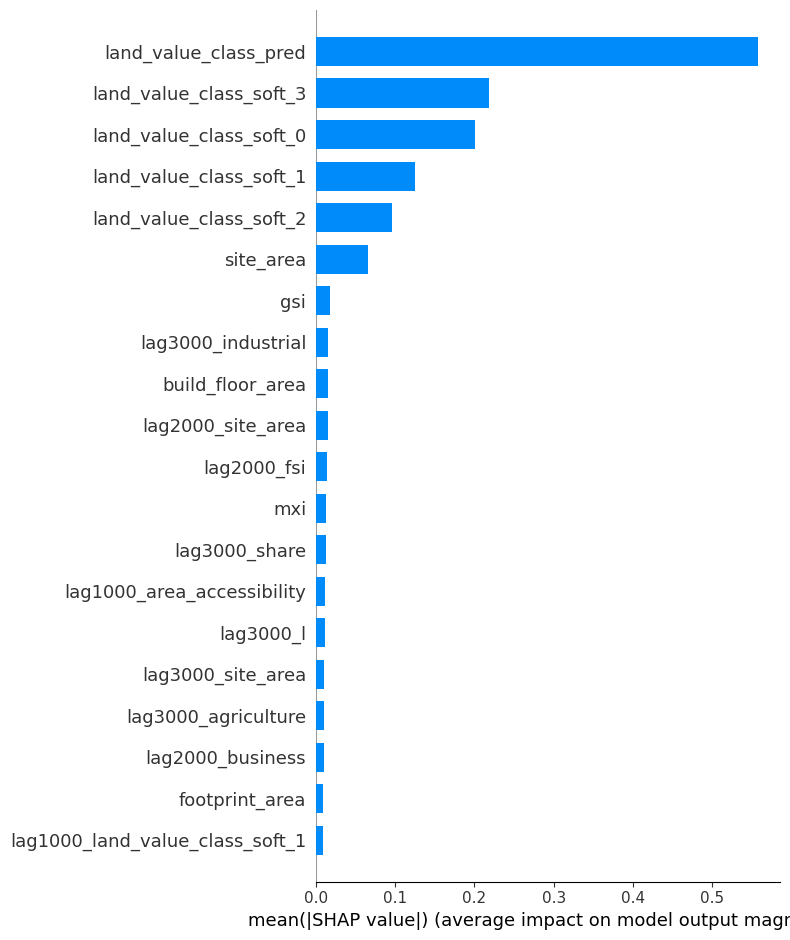

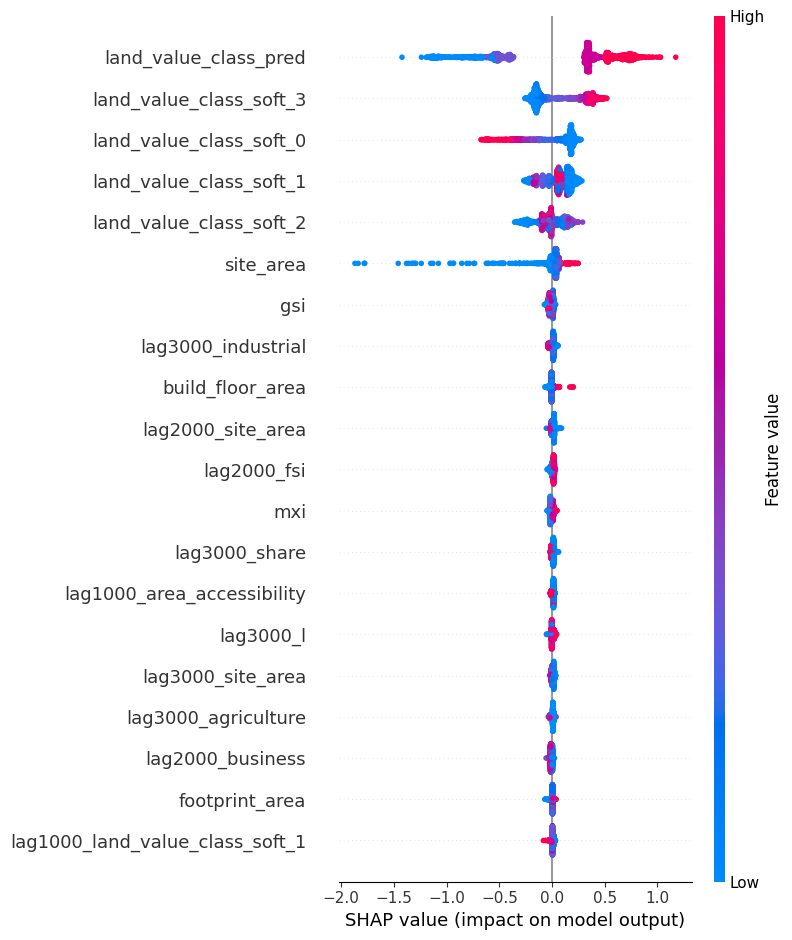

In [8]:
from catboost import Pool
from urbanomy.methods.land_value_modeling.training_utils import spatial_groups, build_radii_weights, add_lags_full_df, feature_names
from sklearn.model_selection import GroupKFold
import shap

# 1) same outer split as in training (pick first fold)
groups = spatial_groups(blocks, cfg.n_clusters, random_state=cfg.seed)
_, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(blocks, blocks[target_col], groups))[0]
df_test = blocks.iloc[test_idx].copy()

# 2) compute lags on FULL dataset once (so test "sees" neighbors from all blocks),
# then slice out test rows
cat_features = list(cfg.cat_features)
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col]

blocks_all = blocks.copy()
for c in cat_features:
    blocks_all[c] = blocks_all[c].astype("string").fillna("missing")

weights = build_radii_weights(blocks_all, cfg.radius_list)
blocks_lag = add_lags_full_df(blocks_all, weights=weights, numeric_cols=numeric_feats)

# 3) final feature list = base feature_cols + computed lag / n_neighbors cols
base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + cat_features))
feats = feature_names(blocks_lag, base_cols_for_model, target_col)

df_test_lag = blocks_lag.loc[df_test.index]

# 4) sample for SHAP
sample_df = df_test_lag[feats].sample(n=min(1500, len(df_test_lag)), random_state=42)
sample_pool = Pool(sample_df, cat_features=cat_features, feature_names=feats)

# 5) SHAP
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(sample_pool, check_additivity=False)

shap.summary_plot(shap_vals, sample_df, plot_type="bar")
shap.summary_plot(shap_vals, sample_df)


In [9]:
# === Trust Report for WAPE: holdout + CI + baselines + segment stability ===
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold

# ---------- helpers ----------
def to_original_scale(x, target_col: str):
    x = np.asarray(x)
    return np.expm1(x) if target_col.startswith("log_") else x

def wape(y_true, y_pred, eps: float = 1e-12):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    denom = np.sum(np.abs(y_true[mask]))
    if denom <= eps:
        return np.nan
    return np.sum(np.abs(y_true[mask] - y_pred[mask])) / denom

def bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = []
    idx_all = np.arange(n)
    for _ in range(n_boot):
        idx = rng.choice(idx_all, size=n, replace=True)
        vals.append(wape(y_true[idx], y_pred[idx]))
    vals = np.asarray(vals)
    return np.nanpercentile(vals, 100 * alpha / 2), np.nanpercentile(vals, 100 * (1 - alpha / 2))

# ---------- data ----------
data_df = blocks.copy()  # важно: используем blocks_clean
target_col = cfg.target_col
cat_features = [c for c in cfg.cat_features if c in data_df.columns]
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

weights = build_radii_weights(data_df, cfg.radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)
base_cols_for_model = list(dict.fromkeys([c for c in cfg.feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# ---------- holdout split (grouped) ----------
groups = spatial_groups(data_lag, cfg.n_clusters, random_state=cfg.seed)
train_idx, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(data_lag, data_lag[target_col], groups))[0]

df_train = data_lag.iloc[train_idx].copy()
df_test = data_lag.iloc[test_idx].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# ---------- point model (MAE) ----------
model_eval = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=max(cfg.iterations * 2, 3000),
    od_type="Iter",
    od_wait=cfg.od_wait,
    bootstrap_type="Bayesian",
    grow_policy="SymmetricTree",
    random_seed=cfg.seed,
    verbose=0,
)
model_eval.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)

y_true = to_original_scale(df_test[target_col].to_numpy(), target_col)
y_pred = to_original_scale(model_eval.predict(df_test[feats]), target_col)

# ---------- main WAPE + CI ----------
wape_holdout = wape(y_true, y_pred)
wape_ci_low, wape_ci_high = bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=cfg.seed)

# ---------- baselines ----------
# 1) global median baseline
train_target_orig = to_original_scale(df_train[target_col].to_numpy(), target_col)
pred_med = np.full_like(y_true, np.median(train_target_orig), dtype=float)
wape_med = wape(y_true, pred_med)

# 2) median by land_use baseline (если есть)
if "land_use" in df_train.columns and "land_use" in df_test.columns:
    med_by_land_use = (
        pd.DataFrame({"land_use": df_train["land_use"].astype("string"), "y": train_target_orig})
        .groupby("land_use")["y"].median()
    )
    global_med = float(np.median(train_target_orig))
    pred_lu = df_test["land_use"].astype("string").map(med_by_land_use).fillna(global_med).to_numpy(float)
    wape_lu = wape(y_true, pred_lu)
else:
    wape_lu = np.nan

# ---------- segment stability ----------
eval_df = df_test.copy()
eval_df["y_true"] = y_true
eval_df["y_pred"] = y_pred
eval_df["abs_err"] = np.abs(eval_df["y_true"] - eval_df["y_pred"])

# by land_use
if "land_use" in eval_df.columns:
    seg_land_use = (
        eval_df.groupby("land_use", dropna=False)
        .apply(lambda g: pd.Series({
            "n": len(g),
            "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
        }))
        .sort_values("wape")
    )
else:
    seg_land_use = pd.DataFrame()

# by y_true decile
eval_df["price_decile"] = pd.qcut(eval_df["y_true"], q=10, labels=False, duplicates="drop")
seg_decile = (
    eval_df.groupby("price_decile", dropna=False)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
    }))
    .sort_index()
)

# ---------- report ----------
print("=== WAPE Trust Report ===")
if "metrics" in locals() and isinstance(metrics, dict) and "wape" in metrics:
    print(f"OOF CV WAPE: {metrics['wape']:.4f}  (std: {metrics.get('wape_std', np.nan):.4f})")
print(f"Holdout WAPE: {wape_holdout:.4f}")
print(f"Holdout WAPE 95% CI (bootstrap): [{wape_ci_low:.4f}, {wape_ci_high:.4f}]")
print(f"Baseline WAPE (global median): {wape_med:.4f}")
if np.isfinite(wape_lu):
    print(f"Baseline WAPE (median by land_use): {wape_lu:.4f}")

print("\nTop segments by land_use (lower WAPE is better):")
display(seg_land_use.head(15))

print("\nWAPE by price decile:")
display(seg_decile)


=== WAPE Trust Report ===
OOF CV WAPE: 40.9476  (std: 2.0265)
Holdout WAPE: 0.3898
Holdout WAPE 95% CI (bootstrap): [0.3724, 0.4080]
Baseline WAPE (global median): 0.8190
Baseline WAPE (median by land_use): 0.7973

Top segments by land_use (lower WAPE is better):


/tmp/ipykernel_33880/2774664744.py:107: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_33880/2774664744.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,n,wape
land_use,,
BUSINESS,125.00,0.32
SPECIAL,19.00,0.33
INDUSTRIAL,81.00,0.33
TRANSPORT,146.00,0.35
RESIDENTIAL,"1,054.00",0.39
AGRICULTURE,13.00,0.41
RECREATION,211.00,0.56



WAPE by price decile:


,n,wape
price_decile,,
0,165.00,3.74
1,165.00,1.04
2,165.00,0.81
3,165.00,0.51
4,165.00,0.36
5,164.00,0.27
6,165.00,0.37
7,165.00,0.34
8,165.00,0.27


In [10]:
# import json

# artifacts = {
#     "feature_cols": list(cfg.feature_cols),
#     "cat_features": list(cfg.cat_features),
#     "radius_list": list(cfg.radius_list),
#     "target_col": cfg.target_col,
#     "n_clusters": cfg.n_clusters,
#     "seed": cfg.seed,
# }

# with open("artifacts.json", "w") as f:
#     json.dump(artifacts, f, indent=2)

In [11]:
# with open("metrics.json", "w") as f:
#     json.dump(metrics, f, indent=2)

In [12]:


# model_path = "land_value_catboost_24_02_2026.cbm"
# model.save_model(model_path)

# print(f"Model saved to {model_path}")

In [15]:
# === Build lag features exactly for model inference + correct error metrics ===
import re
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
)

# ---------------------------
# INPUTS (set these)
# ---------------------------
MODEL = model                  # trained CatBoost model
data_df = blocks.copy()        # dataframe for prediction
target_col = "land_value"      # real target for error calc (if exists)
model_predicts_log1p = False   # True if model outputs log1p(target)

# ---------------------------
# 1) Feature schema from trained model
# ---------------------------
model_features = list(MODEL.feature_names_)

# radii used in lag-features (parsed from model feature names)
radii = sorted({
    int(m.group(1))
    for f in model_features
    for m in [re.match(r"lag(\d+)_", f), re.match(r"n_neighbors_(\d+)$", f)]
    if m is not None
})
if not radii:
    raise ValueError("No lag radii found in model.feature_names_ (no lag* / n_neighbors_* columns).")

# cat features: if cfg exists -> use it; else infer from current data + model base cols
if "cfg" in globals() and hasattr(cfg, "cat_features"):
    cat_features = [c for c in cfg.cat_features if c in data_df.columns]
else:
    lag_like = [c for c in model_features if c.startswith("lag") or c.startswith("n_neighbors_")]
    base_model_cols = [c for c in model_features if c not in lag_like]
    cat_features = [
        c for c in base_model_cols
        if c in data_df.columns and str(data_df[c].dtype) in ["object", "category", "string"]
    ]

# numeric base features for lag computation:
# use either cfg.feature_cols or infer from model features (exclude lag + neighbors + cats)
if "cfg" in globals() and hasattr(cfg, "feature_cols"):
    numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c in data_df.columns]
else:
    numeric_feats = []
    for f in model_features:
        if f.startswith("lag") or f.startswith("n_neighbors_"):
            continue
        if f in cat_features:
            continue
        if f in data_df.columns:
            numeric_feats.append(f)
    numeric_feats = list(dict.fromkeys(numeric_feats))

# ---------------------------
# 2) Build lag features on full dataframe (same logic as training utils)
# ---------------------------
work_df = data_df.copy()
prep_cat_inplace(work_df, cat_features)

weights = build_radii_weights(work_df, radii)
data_lag = add_lags_full_df(work_df, weights=weights, numeric_cols=numeric_feats)

# strict check: all model features must exist
missing = [f for f in model_features if f not in data_lag.columns]
if missing:
    raise ValueError(
        f"After lag build, model features are still missing ({len(missing)}): "
        f"{missing[:20]}{' ...' if len(missing) > 20 else ''}"
    )

# ---------------------------
# 3) Predict
# ---------------------------
X_pred = data_lag[model_features].copy()
y_pred = np.asarray(MODEL.predict(X_pred)).reshape(-1)
if model_predicts_log1p:
    y_pred = np.expm1(y_pred)

out_df = data_lag.copy()
out_df["land_value_pred"] = y_pred

# ---------------------------
# 4) Per-object error % + total MAPE/WAPE (in %)
# ---------------------------
if target_col in out_df.columns:
    y_true = out_df[target_col].astype(float).to_numpy()
    y_hat = out_df["land_value_pred"].astype(float).to_numpy()

    mask = np.isfinite(y_true) & np.isfinite(y_hat) & (y_true > 0)
    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_hat[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    # MAPE (%)
    mape_pct = float(np.mean(np.abs((y_hat[mask] - y_true[mask]) / y_true[mask])) * 100.0)

    # WAPE (%): sum abs error / sum abs true
    wape_pct = float(
        np.sum(np.abs(y_hat[mask] - y_true[mask])) / np.sum(np.abs(y_true[mask])) * 100.0
    )

    print(f"Rows used in error metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE (%): {mape_pct:.4f}")
    print(f"WAPE (%): {wape_pct:.4f}")

    display(
        out_df[[target_col, "land_value_pred", "error_pct"]].head(20)
    )
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[["land_value_pred"]].head(20))

# optional save
# blocks_with_lags_and_pred = out_df



Rows used in error metrics: 8552 / 8552
MAPE (%): 99.9999
WAPE (%): 100.0000


,land_value,land_value_pred,error_pct
0,"129,202,173.99",18.66,100.00
1,"185,946,167.88",19.10,100.00
2,"189,788,550.29",19.20,100.00
3,"373,309,691.92",19.34,100.00
4,"56,148,855.34",17.53,100.00
5,"31,138,079.66",17.24,100.00
6,"280,980.68",12.68,100.00
7,"164,566,674.04",19.35,100.00
8,"186,865,799.42",19.20,100.00
9,"80,765,856.62",18.36,100.00


In [14]:
from urbanomy.methods.land_value_modeling.training_utils import to_original_scale, mape, wape
import numpy as np

# что было в обучении
print("cfg.target_col =", cfg.target_col)

# true/pred в той же шкале, что в fit:
# если модель обучалась на log_*, y_true_raw и y_pred_raw должны быть log-значениями
# и then to_original_scale сделает expm1
y_pred_raw = np.asarray(model.predict(X_pred)).reshape(-1)
y_true_raw = data_lag[cfg.target_col].to_numpy()   # ВАЖНО: тот же target_col, что в train

y_true_eval = to_original_scale(y_true_raw, target_col=cfg.target_col)
y_pred_eval = to_original_scale(y_pred_raw, target_col=cfg.target_col)

mape_ratio = mape(y_true_eval, y_pred_eval)   # 0.05 == 5%
wape_ratio = wape(y_true_eval, y_pred_eval)

print("MAPE ratio:", mape_ratio, "MAPE %:", mape_ratio * 100)
print("WAPE ratio:", wape_ratio, "WAPE %:", wape_ratio * 100)


cfg.target_col = log_land_value
MAPE ratio: 2.9726128247949966 MAPE %: 297.26128247949964
WAPE ratio: 0.3260815011750761 WAPE %: 32.60815011750761
